# Notebook 01 — Klastering Pelanggan: Analisis RFM

**Fase 2 · Minilab EduBI · Data Mining**

---

## Tujuan
Melakukan segmentasi pelanggan menggunakan analisis **RFM (Recency, Frequency, Monetary)**
dengan algoritma **K-Means Clustering**.

Hasil segmentasi membantu manajemen memahami profil pelanggan:
- **Champions** — baru beli, sering, nilai tinggi
- **Loyal Customers** — sering beli, nilai stabil
- **At Risk** — dulu aktif, kini tidak
- **Lost** — lama tidak beli, nilai rendah

## Alur
```
ClickHouse gold.gold_sales_daily
    ↓
Hitung RFM per customer_id
    ↓
Normalisasi fitur (StandardScaler)
    ↓
K-Means Clustering (tentukan k optimal via Elbow + Silhouette)
    ↓
Interpretasi & visualisasi cluster
    ↓
Log eksperimen ke MLflow
```

## Referensi
- Hughes, A.M. (1994). *Strategic Database Marketing*
- Scikit-learn KMeans: https://scikit-learn.org/stable/modules/clustering.html#k-means

---
## 1. Setup & Koneksi

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import clickhouse_connect
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Konfigurasi
CH_HOST  = os.getenv('CH_HOST', 'localhost')
CH_PORT  = int(os.getenv('CH_PORT', 8123))
CH_USER  = os.getenv('CH_USER', 'default')
CH_PASS  = os.getenv('CH_PASSWORD', '')
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('01_clustering_rfm')

print(f'ClickHouse: {CH_HOST}:{CH_PORT}')
print(f'MLflow    : {MLFLOW_URI}')

ClickHouse: clickhouse:8123
MLflow    : http://mlflow:5000


In [2]:
# Koneksi ke ClickHouse
client = clickhouse_connect.get_client(
    host=CH_HOST, port=CH_PORT,
    username=CH_USER, password=CH_PASS
)
print('Koneksi ClickHouse berhasil.')
print('Database tersedia:', client.query('SHOW DATABASES').result_rows)

Koneksi ClickHouse berhasil.
Database tersedia: [('INFORMATION_SCHEMA',), ('bronze',), ('default',), ('gold',), ('information_schema',), ('silver',), ('system',)]


---
## 2. Load Data dari Silver Layer


In [3]:
# query = """
# SELECT
#     customer_id,
#     max(order_date)                          AS last_order_date,
#     count(order_id)                          AS frequency,
#     sum(total_revenue)                       AS monetary
# FROM gold.gold_sales_daily
# GROUP BY customer_id
# """
query = """
SELECT
    customer_id,
    max(order_date)   AS last_order_date,
    count(order_id)   AS frequency,
    sum(total_price)  AS monetary
FROM silver.silver_sales
WHERE status = 'done'
GROUP BY customer_id
"""

df_raw = client.query_df(query)
print(f'Jumlah pelanggan unik: {len(df_raw)}')
df_raw.head()

Jumlah pelanggan unik: 10


,customer_id,last_order_date,frequency,monetary
0,C010,2024-01-28,1,1500000.00
1,C005,2024-01-15,1,1200000.00
2,C009,2024-01-25,1,650000.00
3,C007,2024-01-20,1,900000.00
4,C002,2024-01-07,1,700000.00


---
## 3. Hitung Nilai RFM

In [4]:
import datetime

reference_date = pd.Timestamp.today()

df_rfm = df_raw.copy()
df_rfm['last_order_date'] = pd.to_datetime(df_rfm['last_order_date'])
df_rfm['recency']   = (reference_date - df_rfm['last_order_date']).dt.days
df_rfm['frequency'] = df_rfm['frequency'].astype(int)
df_rfm['monetary']  = df_rfm['monetary'].astype(float)

df_rfm = df_rfm[['customer_id', 'recency', 'frequency', 'monetary']]
print(df_rfm.describe().round(2))
df_rfm.head(10)

       recency  frequency    monetary
count    10.00       10.0       10.00
mean    803.80        1.0  2650000.00
std       7.71        0.0  2829998.04
min     792.00        1.0   650000.00
25%     798.50        1.0   862500.00
50%     803.50        1.0  1350000.00
75%     809.50        1.0  2650000.00
max     815.00        1.0  8200000.00


,customer_id,recency,frequency,monetary
0,C010,792,1,1500000.0
1,C005,805,1,1200000.0
2,C009,795,1,650000.0
3,C007,800,1,900000.0
4,C002,813,1,700000.0
5,C008,798,1,2200000.0
6,C001,815,1,7500000.0
7,C004,808,1,850000.0
8,C006,802,1,8200000.0
9,C003,810,1,2800000.0


---
## 4. Eksplorasi Distribusi RFM

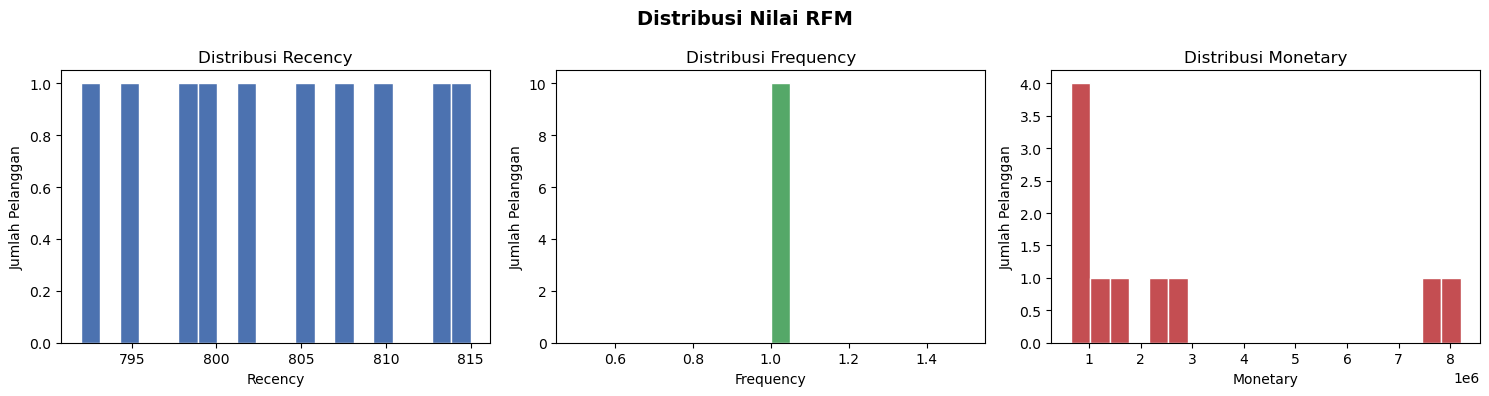

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['recency', 'frequency', 'monetary'],
                          ['#4C72B0', '#55A868', '#C44E52']):
    ax.hist(df_rfm[col], bins=20, color=color, edgecolor='white')
    ax.set_title(f'Distribusi {col.title()}')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Jumlah Pelanggan')
plt.suptitle('Distribusi Nilai RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('experiments/rfm_distribution.png', dpi=100)
plt.show()

---
## 5. Normalisasi Fitur

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(df_rfm[['recency', 'frequency', 'monetary']])
print('Shape setelah normalisasi:', X.shape)
print('Mean :', X.mean(axis=0).round(4))
print('Std  :', X.std(axis=0).round(4))

Shape setelah normalisasi: (10, 3)
Mean : [0. 0. 0.]
Std  : [1. 0. 1.]


---
## 6. Tentukan Jumlah Cluster Optimal (Elbow + Silhouette)

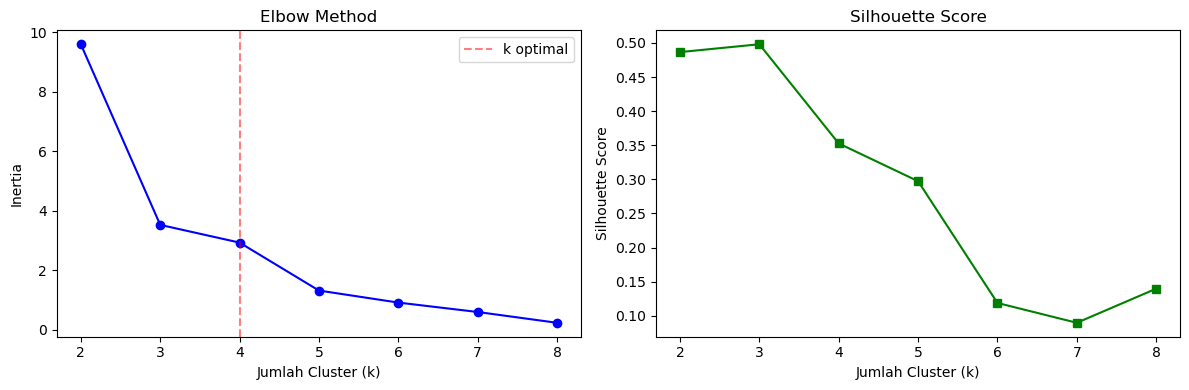

Silhouette score terbaik: k=3 (0.4981)


In [7]:
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, 'bo-')
ax1.set(xlabel='Jumlah Cluster (k)', ylabel='Inertia', title='Elbow Method')
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='k optimal')
ax1.legend()

ax2.plot(list(k_range), silhouettes, 'gs-')
ax2.set(xlabel='Jumlah Cluster (k)', ylabel='Silhouette Score', title='Silhouette Score')
plt.tight_layout()
plt.savefig('experiments/rfm_elbow.png', dpi=100)
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Silhouette score terbaik: k={best_k} ({max(silhouettes):.4f})')

---
## 7. Training Model K-Means & Log ke MLflow

In [8]:
N_CLUSTERS = 4  # Sesuaikan berdasarkan hasil Elbow/Silhouette di atas

with mlflow.start_run(run_name=f'kmeans_k{N_CLUSTERS}'):
    km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
    df_rfm['cluster'] = km_final.fit_predict(X)

    score = silhouette_score(X, df_rfm['cluster'])

    # Log parameter dan metrik
    mlflow.log_param('n_clusters',  N_CLUSTERS)
    mlflow.log_param('scaler',      'StandardScaler')
    mlflow.log_metric('silhouette_score', score)
    mlflow.log_metric('inertia',    km_final.inertia_)

    # Log model
    mlflow.sklearn.log_model(km_final, 'kmeans_model')

    # Log artefak
    mlflow.log_artifact('experiments/rfm_distribution.png')
    mlflow.log_artifact('experiments/rfm_elbow.png')

    print(f'K-Means k={N_CLUSTERS} | Silhouette: {score:.4f} | Inertia: {km_final.inertia_:.2f}')
    print('Run berhasil di-log ke MLflow.')

K-Means k=4 | Silhouette: 0.3527 | Inertia: 2.92
Run berhasil di-log ke MLflow.


---
## 8. Interpretasi Cluster

In [9]:
# Profil rata-rata tiap cluster
profile = df_rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(2)
profile['jumlah_pelanggan'] = df_rfm.groupby('cluster').size()
profile = profile.sort_values('monetary', ascending=False)

# Label segmen berdasarkan profil
def label_segment(row):
    if row['recency'] < 30 and row['frequency'] >= 3 and row['monetary'] > 5_000_000:
        return 'Champions'
    elif row['frequency'] >= 2 and row['monetary'] > 3_000_000:
        return 'Loyal Customers'
    elif row['recency'] > 60 and row['monetary'] > 2_000_000:
        return 'At Risk'
    else:
        return 'Lost / New'

profile['segmen'] = profile.apply(label_segment, axis=1)
print(profile)

         recency  frequency   monetary  jumlah_pelanggan      segmen
cluster                                                             
1          808.5        1.0  7850000.0                 2     At Risk
0          799.0        1.0  1550000.0                 2  Lost / New
3          809.0        1.0  1387500.0                 4  Lost / New
2          793.5        1.0  1075000.0                 2  Lost / New


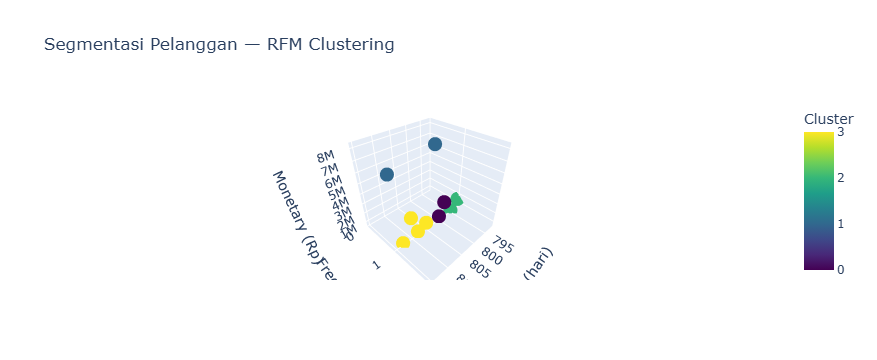

In [10]:
# Visualisasi Scatter 3D RFM
fig = px.scatter_3d(
    df_rfm, x='recency', y='frequency', z='monetary',
    color='cluster', color_continuous_scale='Viridis',
    title='Segmentasi Pelanggan — RFM Clustering',
    labels={'recency': 'Recency (hari)', 'frequency': 'Frequency',
            'monetary': 'Monetary (Rp)', 'cluster': 'Cluster'}
)
fig.show()
fig.write_html('experiments/rfm_3d_scatter.html')

---
## 9. Kesimpulan

**Pertanyaan Diskusi:**
1. Mengapa RFM menggunakan tiga dimensi, bukan satu?
2. Apa implikasi bisnis dari setiap segmen yang ditemukan?
3. Bagaimana cara meningkatkan kualitas segmentasi jika data pelanggan lebih banyak?
4. Apakah hasil clustering akan berbeda jika tidak dilakukan normalisasi? Mengapa?

**Lihat hasil eksperimen di MLflow:** http://localhost:5000